# Measurement of Seasonal Indices by Ratio to Moving Average Method 

## Viva Q&A

<font size = "5"> 

Q1: What is the biggest advantage of the Moving Average method compared to the Linear Trend method (Practical 5)?
Answer: A Linear Trend assumes growth happens in a perfectly straight line forever. A Moving Average is flexible; it curves and adapts if the business speeds up, slows down, or changes direction over time.

Q2: Why do we use a 12-month window for the moving average?
Answer: Because our data repeats yearly. A 12-month window perfectly captures one full seasonal cycle, absorbing the extreme highs (summer) and lows (winter) to leave behind only the underlying trend.

Q3: Why do we have to "Center" the moving average using a 2-period rolling window?
Answer: Because 12 is an even number, its true middle point falls exactly halfway between two months (Month 6.5). We use a 2-period average to mathematically push the value onto a whole month (Month 7) so it aligns correctly with our actual data.

Q4: Why does the resulting CMA column have NaN (blank) values at the beginning and end of the dataset?
Answer: Because a centered 12-month moving average requires data from both the past and the future to calculate the middle. The first 6 months don't have enough past data, and the last 6 months don't have enough future data, so they are left blank.

Q5: How do we eliminate random/irregular noise in this method?
Answer: By grouping all the same months together (e.g., all Januaries) and calculating their mean. This cancels out any random, unusual shocks that happened in a specific year. 

</font>

Measuremnt of Seasonal Indices by Ratio to Moving Average Method
Final Seasonal Indices
Sum of adjusted indices: 1200.0000


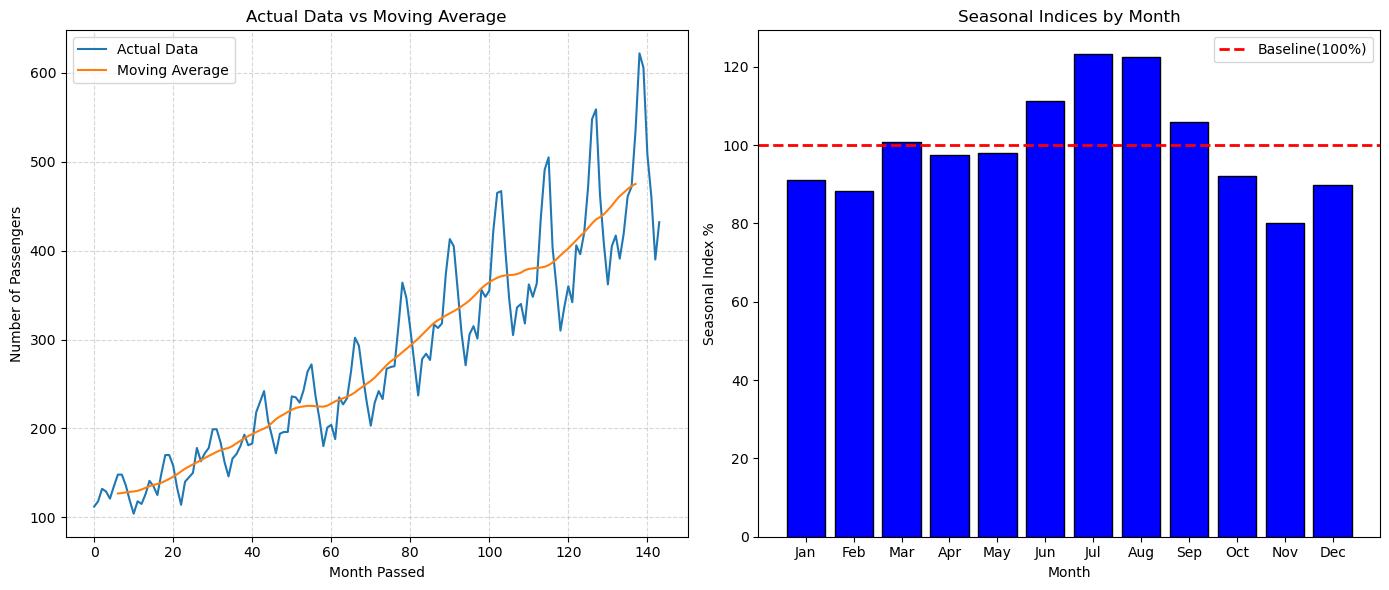

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 

warnings.filterwarnings("ignore")

def ratio_to_moving_average():
    print("Measuremnt of Seasonal Indices by Ratio to Moving Average Method")
    df = sns.load_dataset("flights")
    df["12-Months MA"] = df["passengers"].rolling(window=12).mean()

    df["CMA"] = df["12-Months MA"].rolling(window=2).mean().shift(-6)

    df["Ratio_To_MA"] = (df["passengers"]/df["CMA"])*100

    unadjusted_indices = df.dropna().groupby("month")["Ratio_To_MA"].mean()
    total_unadjusted = unadjusted_indices.sum()
    adjustment_factor = 1200/total_unadjusted
    adjusted_indices = unadjusted_indices * adjustment_factor

    result_df = pd.DataFrame({"Unadjusted Index":unadjusted_indices,
                              "Adjusted Index":adjusted_indices}).round(2)
    print("Final Seasonal Indices")
    print(f"Sum of adjusted indices: {adjusted_indices.sum():.4f}")

    fig, axes = plt.subplots(1,2,figsize=(14,6))

    axes[0].plot(df.index,df["passengers"],label="Actual Data")
    axes[0].plot(df.index,df["CMA"],label="Moving Average")
    axes[0].set_title("Actual Data vs Moving Average")
    axes[0].set_xlabel("Month Passed")
    axes[0].set_ylabel("Number of Passengers")
    axes[0].legend()
    axes[0].grid(True,linestyle="--",alpha=0.5)

    axes[1].bar(adjusted_indices.index,adjusted_indices.values,color="blue",edgecolor="black")
    axes[1].axhline(y=100,linestyle="--",linewidth=2,color="red",label="Baseline(100%)")
    axes[1].set_title("Seasonal Indices by Month")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Seasonal Index %")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    ratio_to_moving_average()
    